<a href="https://colab.research.google.com/github/Thomas-Fabbris/applied-statistics-polimi/blob/main/Labs/Lab_VIII_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab VIII - Neural Networks 101**</font>

# Import

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected:", gpus[0].name)
else:
    print("No GPU detected. Training will run on CPU.")

GPU detected: /physical_device:GPU:0


# Load Adult Income Dataset

In [ ]:
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K




The task is binary classification:

$
y =
\begin{cases}
1 & \text{income > 50K}\\
0 & \text{income <= 50K}
\end{cases}
$

In [ ]:
df["class"].value_counts()

,count
class,
<=50K,37155
>50K,11687


The dataset uses `?` for some missing categorical values. We drop rows with missing values for simplicity.

In [ ]:
df = df.replace("?", np.nan).dropna()

df["target"] = (df["class"].astype(str).str.contains(">50K")).astype(int)

X = df.drop(columns=["class", "target"])
y = df["target"]

print("After removing missing values:", X.shape)
print("Outcome distribution:")
print(y.value_counts(normalize=True).rename("proportion"))

After removing missing values: (45222, 14)
Outcome distribution:
target
0    0.752156
1    0.247844
Name: proportion, dtype: float64


# Train / validation / test split

We create three sets:

- **training set**: used to fit model parameters;
- **validation set**: used to monitor learning and tune hyperparameters;
- **test set**: used only at the end for final evaluation.

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (28941, 14)
Validation: (7236, 14)
Test: (9045, 14)


# Preprocessing

Neural networks are sensitive to the scale of input variables.

We therefore:

- standardize numerical variables;
- one-hot encode categorical variables.

The same preprocessing is used for both logistic regression and the neural network, so we can make a fair comparison.

In [ ]:
# Here is a code-way to automatically identify numerical and cat features
# As we have already seen, this approach is not completely reliable and should be double-checked

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

print("Processed train shape:", X_train_proc.shape)

Processed train shape: (28941, 104)


# Neural Network classifier

A simple feed-forward neural network for binary classification with:

1. an input layer;
2. one or more hidden layers;
3. an output layer with one neuron and sigmoid activation.

The output is interpreted as:

$
\hat{p}(y=1 \mid x)
$

The loss function is **binary cross-entropy**, the standard loss for binary classification:

$
\mathcal{L}(y, \hat{y}) =
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)
\right]
$

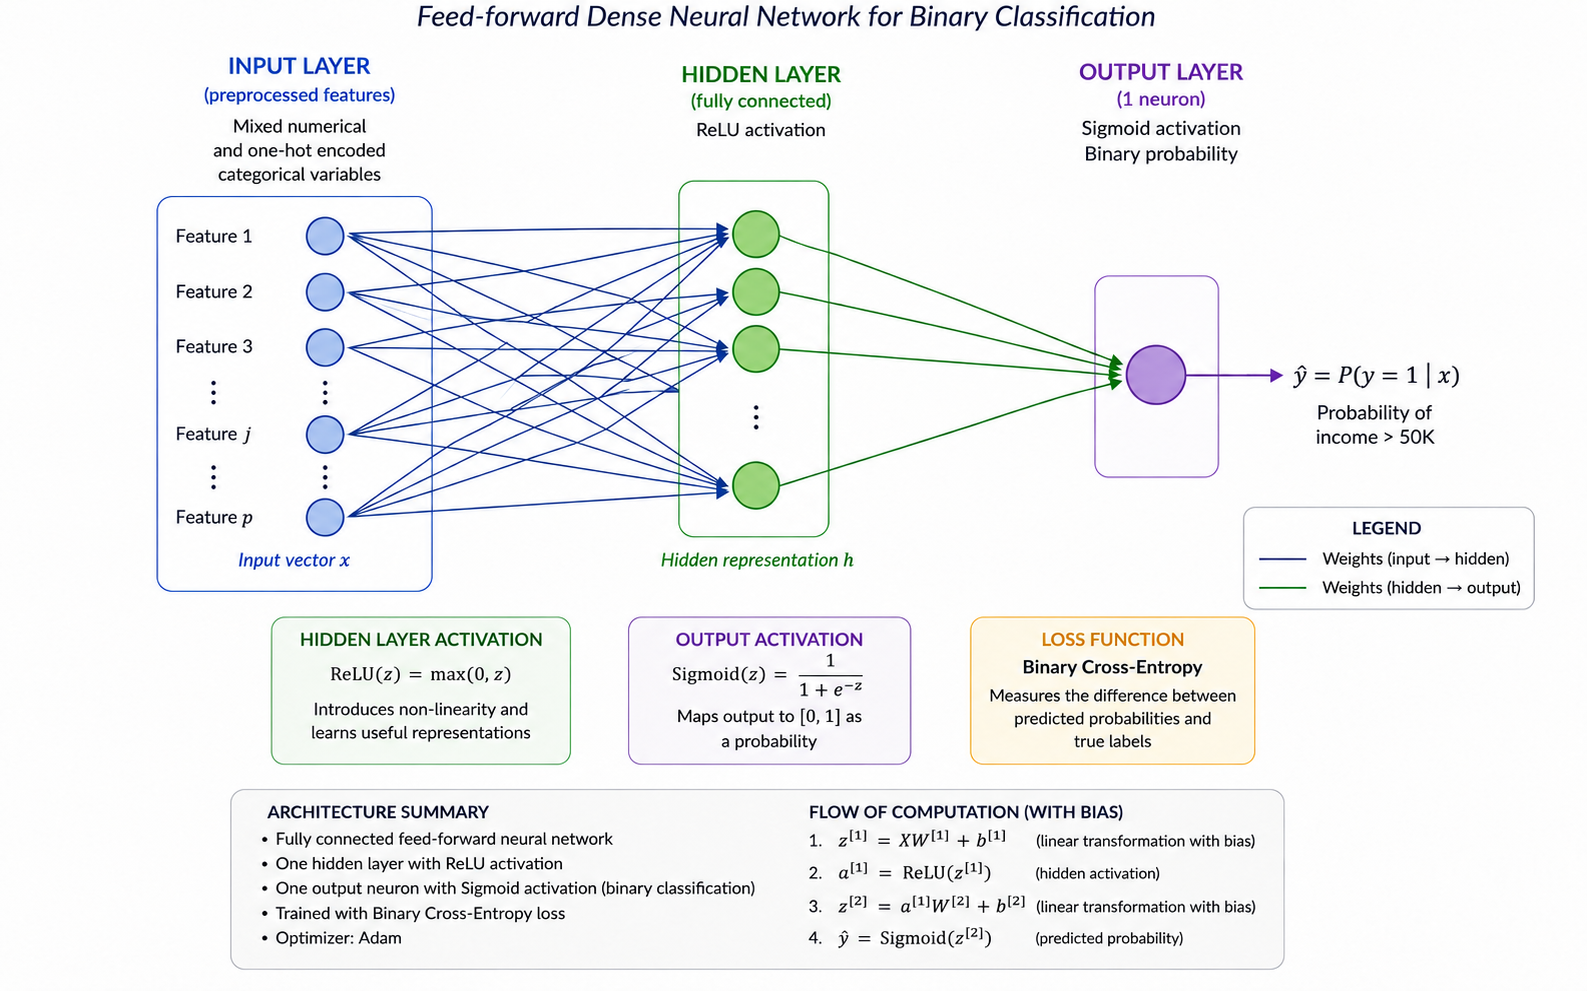

## Implementation

In [ ]:
def build_mlp(
    input_dim,
    hidden_units=32,
    learning_rate=0.001,
):
    """
    Build a simple feed-forward neural network for binary classification.
    """

    model = keras.Sequential(name="simple_mlp")

    # Input layer
    model.add(keras.Input(shape=(input_dim,), name="input"))

    # Hidden layer: linear transformation + nonlinear activation
    model.add(layers.Dense(hidden_units, activation="relu", name="hidden_layer"))

    # Output layer for binary classification
    model.add(layers.Dense(1, activation="sigmoid", name="output"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [ ]:
input_dim = X_train_proc.shape[1]

print("Input dim:", input_dim)

model = build_mlp(
    input_dim=input_dim,
    hidden_units=32,
    learning_rate=0.001
)

model.summary()

Input dim: 104


Model: "simple_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

### Parameter count

For one hidden layer with $h$ neurons and $p$ input features:

$
\text{parameters} = (p+1)h + (h + 1) = h(p+2) + 1
$

The first $(ph+h)$ parameters are in the hidden layer. The final $(h+1)$ parameters are in the output layer.

In [ ]:
p = input_dim
h = 32

manual_parameter_count = h * (p + 2) + 1
print("Manual parameter count:", manual_parameter_count)
print("Keras parameter count:", model.count_params())

Manual parameter count: 3393
Keras parameter count: 3393


## Training

We train the network and store the training history.

The history contains, for each epoch, training and validation loss, and the selected metrics (accuracy and AUC).

In [ ]:
history = model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8043 - auc: 0.8534 - loss: 0.3947 - val_accuracy: 0.8437 - val_auc: 0.9016 - val_loss: 0.3306
Epoch 2/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8494 - auc: 0.9069 - loss: 0.3226 - val_accuracy: 0.8498 - val_auc: 0.9064 - val_loss: 0.3222
Epoch 3/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8516 - auc: 0.9100 - loss: 0.3172 - val_accuracy: 0.8513 - val_auc: 0.9086 - val_loss: 0.3184
Epoch 4/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8530 - auc: 0.9118 - loss: 0.3140 - val_accuracy: 0.8530 - val_auc: 0.9100 - val_loss: 0.3164
Epoch 5/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8542 - auc: 0.9130 - loss: 0.3118 - val_accuracy: 0.8538 - val_auc: 0.9108 - val_loss: 0.3152
Epoch 6/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8551 - auc: 0.9140 - loss: 0.3102 - val_accuracy: 0.8550 - val_auc: 0.9110 - val_loss: 0.3146
Epoch 7/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
def plot_training_history(history):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training loss")
    plt.plot(hist["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["auc"], label="Training AUC")
    plt.plot(hist["val_auc"], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("AUC")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

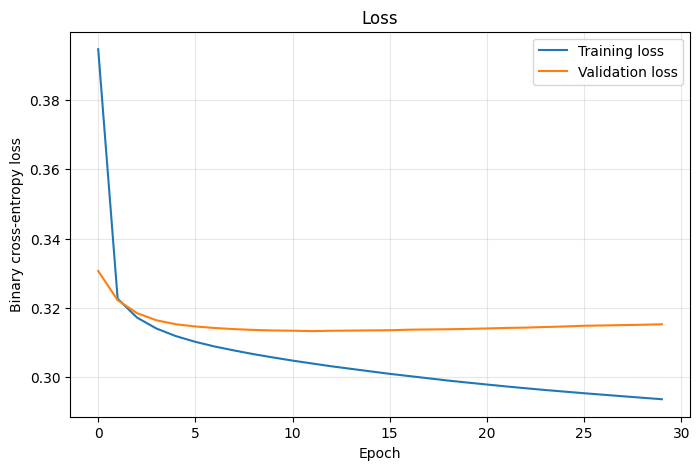

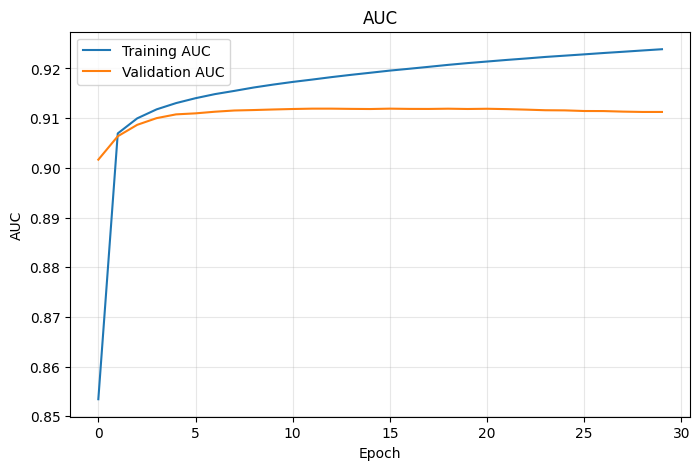

In [ ]:
plot_training_history(history)

## Enlarging the network

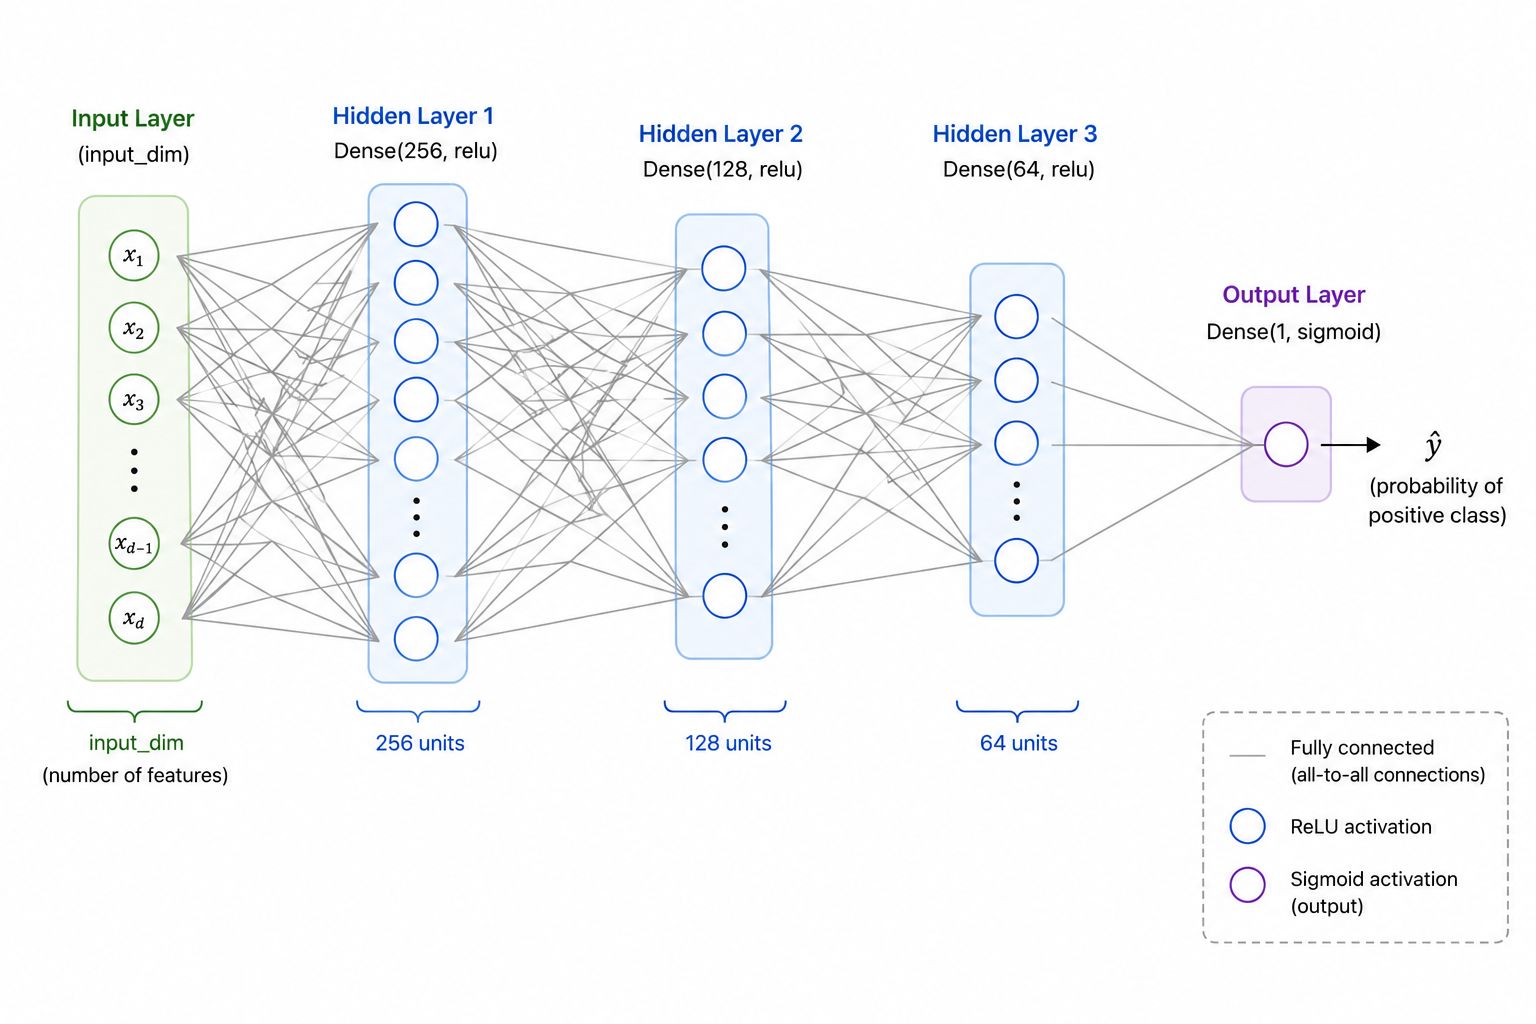

Epoch 1/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8430 - auc: 0.8986 - loss: 0.3343 - val_accuracy: 0.8519 - val_auc: 0.9100 - val_loss: 0.3172
Epoch 2/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8543 - auc: 0.9126 - loss: 0.3129 - val_accuracy: 0.8550 - val_auc: 0.9112 - val_loss: 0.3142
Epoch 3/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8580 - auc: 0.9165 - loss: 0.3064 - val_accuracy: 0.8541 - val_auc: 0.9112 - val_loss: 0.3145
Epoch 4/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8612 - auc: 0.9198 - loss: 0.3004 - val_accuracy: 0.8523 - val_auc: 0.9103 - val_loss: 0.3160
Epoch 5/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8637 - auc: 0.9231 - loss: 0.2944 - val_accuracy: 0.8521 - val_auc: 0.9099 - val_loss: 0.3177
Epoch 6/60
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8674 - auc: 0.9264 - loss: 0.2881 - val_accuracy: 0.8524 - val_auc: 0.9085 - val_loss: 0.3198
Epoch 7/60
453/453 ━━━━━━━━━━━━━━━━━━━━

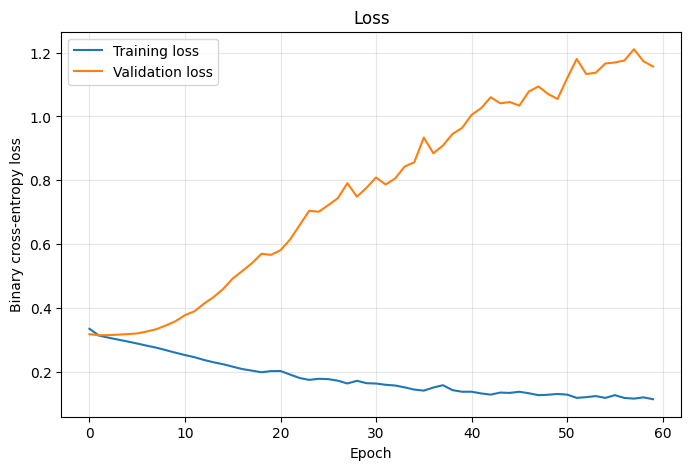

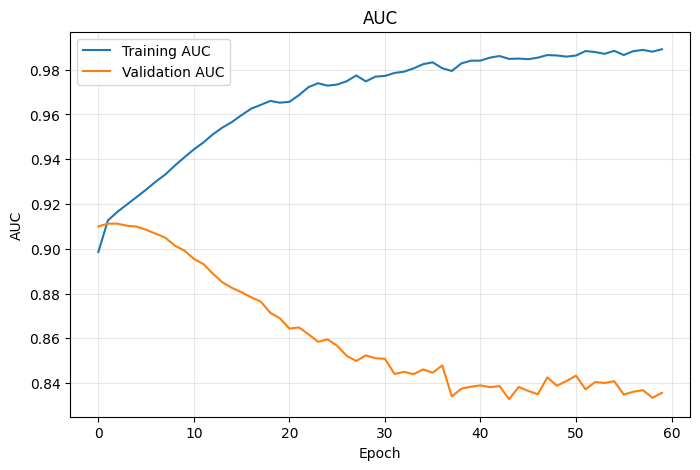

In [ ]:
overfit_model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

overfit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

overfit_history = overfit_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=60,
    batch_size=64,
    verbose=1
)

plot_training_history(overfit_history)

Here overfitting is particularly evident!

## Early stopping

Early stopping monitors validation loss and stops training when the model no longer improves.

Relevant parameters for this are:

- `monitor="val_loss"`: monitor validation loss;
- `patience=5`: wait 5 epochs before stopping;
- `restore_best_weights=True`: return to the best validation-loss epoch.

Epoch 1/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8280 - auc: 0.8802 - loss: 0.3617 - val_accuracy: 0.8469 - val_auc: 0.9047 - val_loss: 0.3251
Epoch 2/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8520 - auc: 0.9096 - loss: 0.3180 - val_accuracy: 0.8513 - val_auc: 0.9080 - val_loss: 0.3192
Epoch 3/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8539 - auc: 0.9121 - loss: 0.3136 - val_accuracy: 0.8517 - val_auc: 0.9095 - val_loss: 0.3169
Epoch 4/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8548 - auc: 0.9137 - loss: 0.3110 - val_accuracy: 0.8524 - val_auc: 0.9102 - val_loss: 0.3159
Epoch 5/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8554 - auc: 0.9150 - loss: 0.3089 - val_accuracy: 0.8520 - val_auc: 0.9105 - val_loss: 0.3153
Epoch 6/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8562 - auc: 0.9160 - loss: 0.3072 - val_accuracy: 0.8524 - val_auc: 0.9107 - val_loss: 0.3149
Epoch 7/100
453/453 ━━━━━━━━━━━━━━

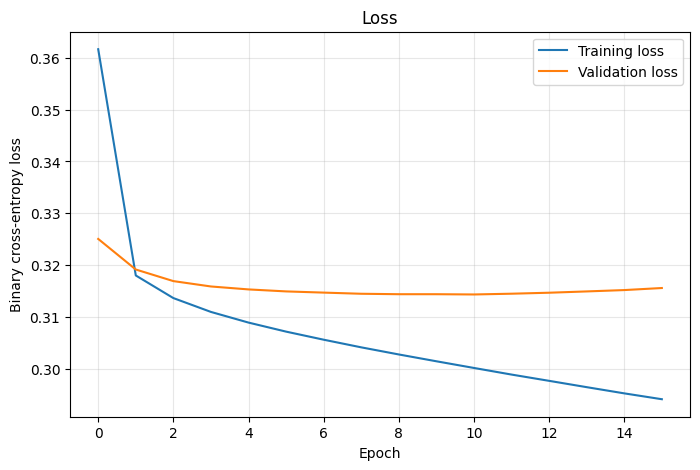

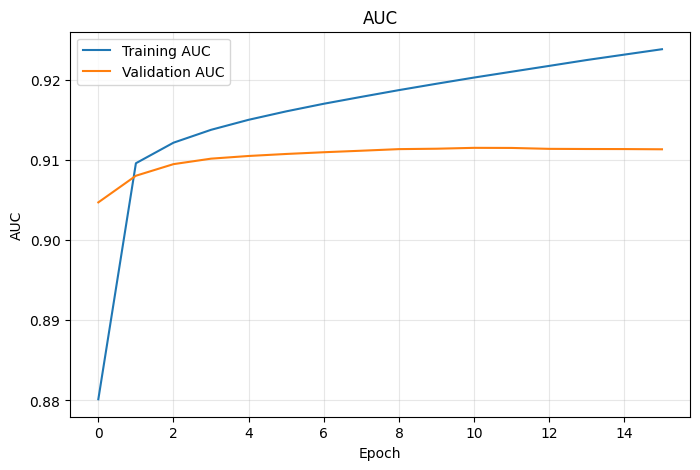

Number of epochs actually run: 16


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

es_model = build_mlp(
    input_dim=input_dim,
    hidden_units=64,
    learning_rate=0.001
)

es_history = es_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(es_history)
print("Number of epochs actually run:", len(es_history.history["loss"]))

## Hyperparameter tuning

We focus on two hyperparameters:

1. **learning rate**: how large each optimization step is;
2. **batch size**: how many observations are used before updating the weights;

We compare their effect on validation loss.

### Effect of learning rate

A learning rate that is too small may train slowly, while a learning rate that is too large may make training unstable.

In [ ]:
def train_for_comparison(
    learning_rate=0.001,
    batch_size=64,
    hidden_units=32,
    epochs=20
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_mlp(
        input_dim=input_dim,
        hidden_units=hidden_units,
        learning_rate=learning_rate
    )

    history = model.fit(
        X_train_proc,
        y_train_np,
        validation_data=(X_val_proc, y_val_np),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    return model, history

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_histories = {}

for lr_value in learning_rates:
    print(f"Training with learning_rate={lr_value}")
    _, hist = train_for_comparison(
        learning_rate=lr_value,
        batch_size=64,
        hidden_units=32,
        epochs=20
    )
    lr_histories[lr_value] = hist

Training with learning_rate=0.0001
Training with learning_rate=0.001
Training with learning_rate=0.01
Training with learning_rate=0.1


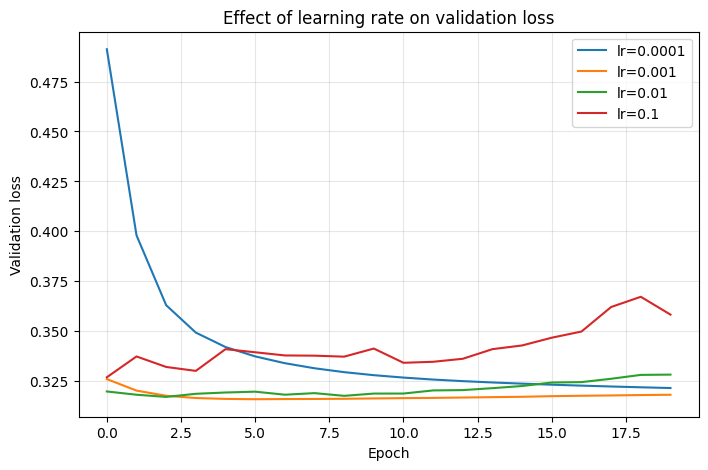

In [ ]:
plt.figure(figsize=(8, 5))

for lr_value, hist in lr_histories.items():
    plt.plot(hist.history["val_loss"], label=f"lr={lr_value}")

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Effect of learning rate on validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Effect of batch size

The batch size determines how many training examples are processed before the model updates its weights. Smaller batch sizes lead to more frequent but noisier updates, while larger batch sizes produce smoother gradient estimates and make more efficient use of hardware resources. In practice, very small batches can result in unstable training, whereas very large batches may converge more slowly and sometimes generalize less effectively. Moderate batch sizes often provide a good compromise between training speed, stability, and predictive performance.  

In [ ]:
batch_sizes = [16, 64, 256, 1024]
batch_histories = {}

for bs in batch_sizes:
    print(f"Training with batch_size={bs}")
    _, hist = train_for_comparison(
        learning_rate=0.001,
        batch_size=bs,
        hidden_units=32,
        epochs=20
    )
    batch_histories[bs] = hist

Training with batch_size=16
Training with batch_size=64
Training with batch_size=256
Training with batch_size=1024


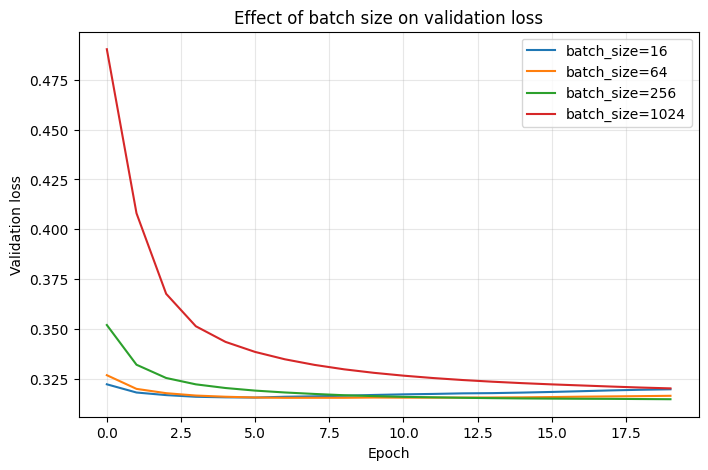

In [ ]:
plt.figure(figsize=(8, 5))

for bs, hist in batch_histories.items():
    plt.plot(hist.history["val_loss"], label=f"batch_size={bs}")

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Effect of batch size on validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### A simple grid search

Here we run a small grid search over hidden units, learning rate, and batch size. We select the configuration with the lowest validation loss.

In [ ]:
results = []

param_grid = {
    "hidden_units": [16, 32, 64],
    "learning_rate": [0.0005, 0.001, 0.005],
    "batch_size": [32, 64, 256]
}

for hidden_units in param_grid["hidden_units"]:
    for learning_rate in param_grid["learning_rate"]:
        for batch_size in param_grid["batch_size"]:

            print(
                f"hidden_units={hidden_units}, "
                f"learning_rate={learning_rate}, "
                f"batch_size={batch_size}"
            )

            tf.keras.backend.clear_session()
            tf.random.set_seed(SEED)

            candidate = build_mlp(
                input_dim=input_dim,
                hidden_units=hidden_units,
                learning_rate=learning_rate
            )

            callback = keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )

            hist = candidate.fit(
                X_train_proc,
                y_train_np,
                validation_data=(X_val_proc, y_val_np),
                epochs=40,
                batch_size=batch_size,
                callbacks=[callback],
                verbose=0
            )

            results.append({
                "hidden_units": hidden_units,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "best_val_loss": np.min(hist.history["val_loss"]),
                "best_val_auc": np.max(hist.history["val_auc"]),
                "epochs_run": len(hist.history["loss"])
            })

results_df = pd.DataFrame(results).sort_values("best_val_loss")
results_df.head(10)

hidden_units=16, learning_rate=0.0005, batch_size=32
hidden_units=16, learning_rate=0.0005, batch_size=64
hidden_units=16, learning_rate=0.0005, batch_size=256
hidden_units=16, learning_rate=0.001, batch_size=32
hidden_units=16, learning_rate=0.001, batch_size=64
hidden_units=16, learning_rate=0.001, batch_size=256
hidden_units=16, learning_rate=0.005, batch_size=32
hidden_units=16, learning_rate=0.005, batch_size=64
hidden_units=16, learning_rate=0.005, batch_size=256
hidden_units=32, learning_rate=0.0005, batch_size=32
hidden_units=32, learning_rate=0.0005, batch_size=64
hidden_units=32, learning_rate=0.0005, batch_size=256
hidden_units=32, learning_rate=0.001, batch_size=32
hidden_units=32, learning_rate=0.001, batch_size=64
hidden_units=32, learning_rate=0.001, batch_size=256
hidden_units=32, learning_rate=0.005, batch_size=32
hidden_units=32, learning_rate=0.005, batch_size=64
hidden_units=32, learning_rate=0.005, batch_size=256
hidden_units=64, learning_rate=0.0005, batch_size=32

,hidden_units,learning_rate,batch_size,best_val_loss,best_val_auc,epochs_run
13,32,0.0010,64,0.313647,0.911619,10
10,32,0.0005,64,0.313694,0.911606,21
23,64,0.0010,256,0.313912,0.911535,18
20,64,0.0005,256,0.314212,0.911467,34
18,64,0.0005,32,0.314229,0.911299,12
19,64,0.0005,64,0.314251,0.911335,18
22,64,0.0010,64,0.314353,0.911252,10
26,64,0.0050,256,0.314463,0.911812,7
17,32,0.0050,256,0.314491,0.911252,8
14,32,0.0010,256,0.314609,0.910947,28


## Train the final neural network

We now take the best hyperparameter configuration and train a final model.

In [ ]:
best_params = results_df.iloc[0].to_dict()
best_params

{'hidden_units': 32.0,
 'learning_rate': 0.001,
 'batch_size': 64.0,
 'best_val_loss': 0.31364724040031433,
 'best_val_auc': 0.9116193056106567,
 'epochs_run': 10.0}

In [ ]:
best_params = {'hidden_units': 32.0,
 'learning_rate': 0.001,
 'batch_size': 64.0}

Epoch 1/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8203 - auc: 0.8691 - loss: 0.3780 - val_accuracy: 0.8445 - val_auc: 0.9015 - val_loss: 0.3308
Epoch 2/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8513 - auc: 0.9075 - loss: 0.3218 - val_accuracy: 0.8491 - val_auc: 0.9068 - val_loss: 0.3215
Epoch 3/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8533 - auc: 0.9103 - loss: 0.3167 - val_accuracy: 0.8506 - val_auc: 0.9090 - val_loss: 0.3182
Epoch 4/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8542 - auc: 0.9118 - loss: 0.3140 - val_accuracy: 0.8532 - val_auc: 0.9098 - val_loss: 0.3166
Epoch 5/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8542 - auc: 0.9130 - loss: 0.3121 - val_accuracy: 0.8536 - val_auc: 0.9103 - val_loss: 0.3158
Epoch 6/100
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8561 - auc: 0.9139 - loss: 0.3105 - val_accuracy: 0.8550 - val_auc: 0.9107 - val_loss: 0.3153
Epoch 7/100
453/453 ━━━━━━━━━━━━━━

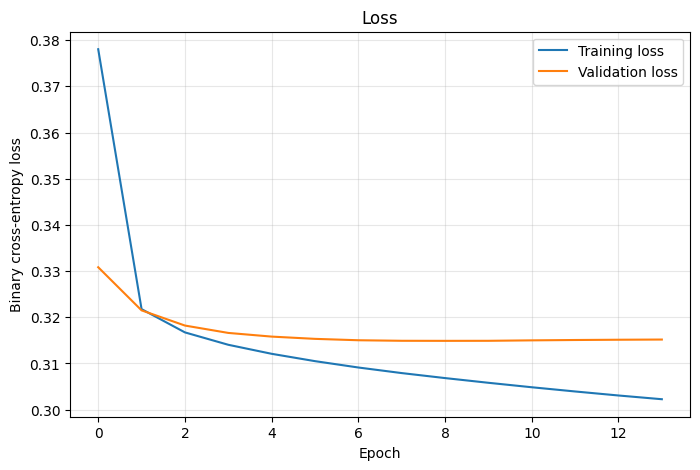

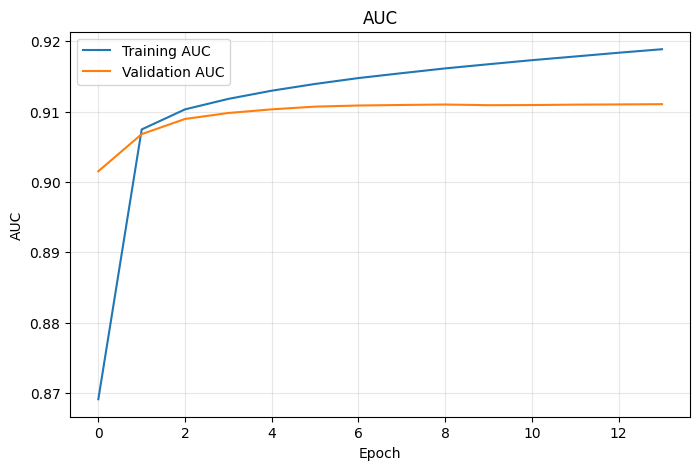

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

final_model = build_mlp(
    input_dim=input_dim,
    hidden_units=int(best_params["hidden_units"]),
    learning_rate=float(best_params["learning_rate"])
)

final_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=100,
    batch_size=int(best_params["batch_size"]),
    callbacks=[final_early_stopping],
    verbose=1
)

plot_training_history(final_history)

## Save and load the model

After training a model we often want to save it and reuse it later.

For a neural network, we save:

1. the trained Keras model;
2. the preprocessing object.

The preprocessing object is essential because the model expects the same transformed input representation used during training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH = '/content/drive/MyDrive/_Polimi/StatAppHPC'
os.chdir(PATH)

In [ ]:
import joblib

os.makedirs("saved_model", exist_ok=True)

final_model.save("saved_model/adult_income_mlp.keras")
joblib.dump(preprocessor, "saved_model/preprocessor.joblib")

print("Model and preprocessor saved.")

Model and preprocessor saved.


In [ ]:
loaded_model = keras.models.load_model("saved_model/adult_income_mlp.keras")
loaded_preprocessor = joblib.load("saved_model/preprocessor.joblib")

X_test_loaded_proc = loaded_preprocessor.transform(X_test).astype("float32")
loaded_test_proba = loaded_model.predict(X_test_loaded_proc).ravel()

print("Loaded model test ROC-AUC:", roc_auc_score(y_test_np, loaded_test_proba))

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Loaded model test ROC-AUC: 0.9099778289553999


# Quiz

Final quiz on supervised learning: https://app.wooclap.com/POQTDOQ?from=instruction-slide

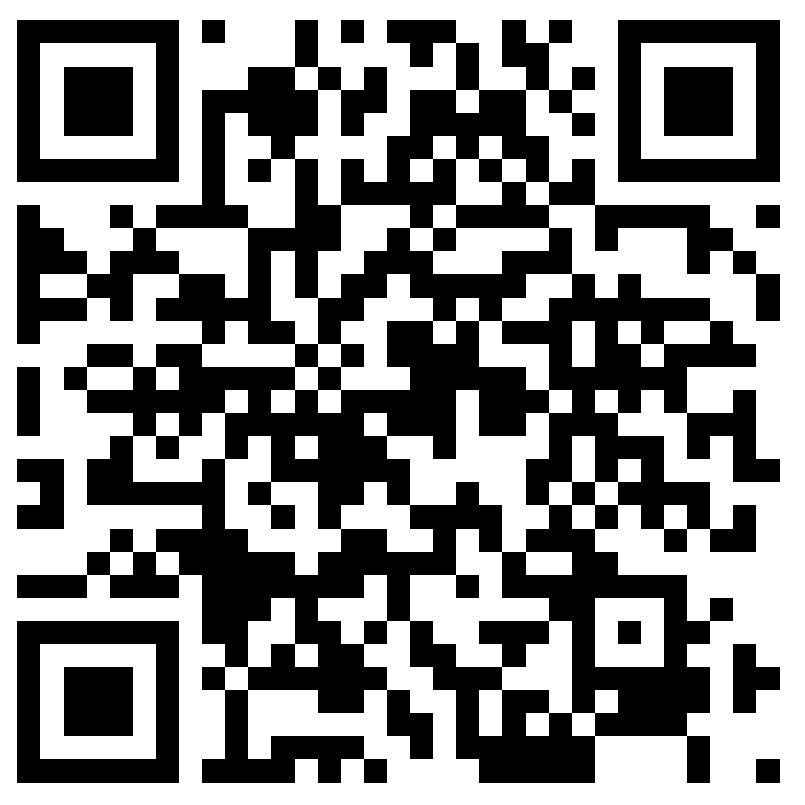

# Supplementary

## Weight decay regularization

Weight decay is a regularization technique that discourages the model from learning excessively large weights, helping to reduce overfitting.

In classical L2 regularization, a penalty term is added to the loss function:

$
\mathcal{L}_{\text{total}}
=
\mathcal{L}_{\text{BCE}}
+
\lambda \sum_{j=1}^{p} w_j^2
$

where:


* $\mathcal{L}_{\text{BCE}}$ is the binary cross-entropy loss,
* $w_j$ are the model parameters,
* $\lambda$ controls the strength of the penalty.


The optimizer therefore minimizes both the prediction error and the magnitude of the weights.

In [ ]:
from tensorflow.keras import layers, regularizers, callbacks

l2_model = keras.Sequential([
    keras.Input(shape=(input_dim,)),

    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),

    layers.Dense(1, activation="sigmoid",
                 kernel_regularizer=regularizers.l2(1e-4))
])

l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

l2_history = l2_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=60,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(l2_history)

AdamW implements regularization differently. Instead of adding a penalty to the loss function, the weights are directly shrunk at every optimization step.

The parameter update can be written as

$
w_{t+1}
=
w_t
-
\eta \hat{g}_t
-
\eta \lambda w_t
$

where:

* $w_t$ is the current weight,
* $\hat{g}_t$ is the Adam-adjusted gradient,
* $\eta$ is the learning rate,
* $\lambda$ is the weight decay coefficient.

The last term,

$
-\eta \lambda w_t,
$

continuously pulls the weights toward zero.

In [ ]:
from tensorflow.keras import layers, callbacks

adamw_model = keras.Sequential([
    keras.Input(shape=(input_dim,)),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

adamw_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

adamw_history = adamw_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=60,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(adamw_history)

## Dropout regularization

In [ ]:
from tensorflow.keras import layers, callbacks

dropout_model = keras.Sequential([
    keras.Input(shape=(input_dim,)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

dropout_history = dropout_model.fit(
    X_train_proc,
    y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=60,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plot_training_history(dropout_history)

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/zEKsx28tPT) (estimated 2 minutes)